# Examen:

Teoria (test 10 min):
    Práctica 7:
        - saber cargar el modleo (create_modle())
        - transformación de la entrada, cargar el config de los datos (necesario para MNIST, CIFAR-10)
    Practica 8:
        - que es un planificador (varia el learning rate), para que se utilizan (guiar el modelo en tiempo de entrenamiento, y obtener mejores resultados), los distintos tipos (CsoneAnnealing, ReduceLROnPlateau, saber que es el warmup[partimos de un larning rate, lo aumentamos en un inicio y luego baja])
    Practica 9:
        - Que son las transformaciones (duplicar datos y modificarlos, aumentar la varianza y generalizar para que el modelo pueda clasiicar mejor), distintos tipos de transformaciones (no hace falta saber todas)
        
Ejercicio (practica 35 min):
    - Controlar schedulers y transformaciones de los datos (pract9, pract8)
    - Entrenamiento por épocas (cortito) -> Lo más importante es el código, no en si los resultados (puede no dar tiempo)



# TL09 Aumento de datos

### 2 transforms v2

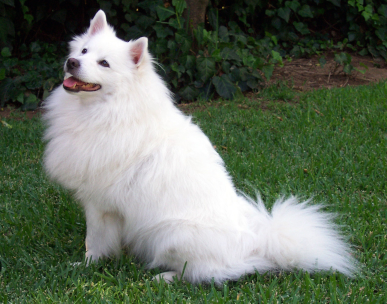

In [18]:
import matplotlib.pyplot as plt
import urllib
from PIL import Image

url = "https://github.com/pytorch/hub/raw/master/images/dog.jpg"
file = "dog.jpg"
urllib.request.urlretrieve(url, file)
img = Image.open(file).convert("RGB")
img.reduce(4)

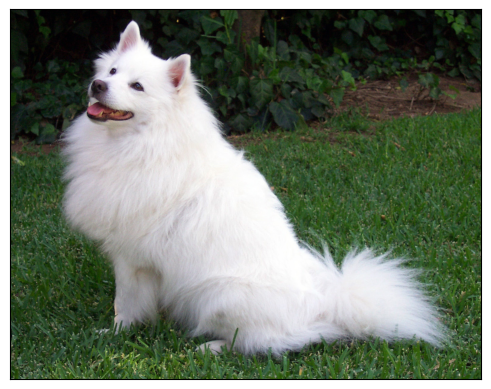

In [19]:
import torch
from torchvision.transforms import v2
# Compose: 
transforms = v2.Compose([v2.ToImage(), v2.ToDtype(torch.uint8, scale=True)])
out = transforms(img)  # Le pasamos la imagen
plt.xticks([])
plt.yticks([])
plt.imshow(out.permute(1, 2, 0).numpy())

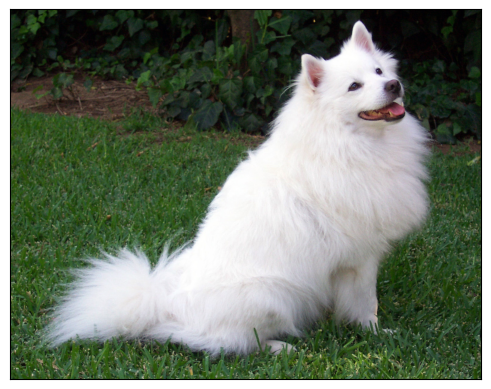

In [20]:
# Le aplicamos una transformación a la imagen recibida con Compose. Le aplicamos un Flip para girar la imagen
transforms = v2.Compose(
    [v2.ToImage(), v2.ToDtype(torch.uint8, scale=True), v2.RandomHorizontalFlip(p=1.0)]
)
out = transforms(img)
plt.xticks([])
plt.yticks([])
plt.imshow(out.permute(1, 2, 0).numpy())

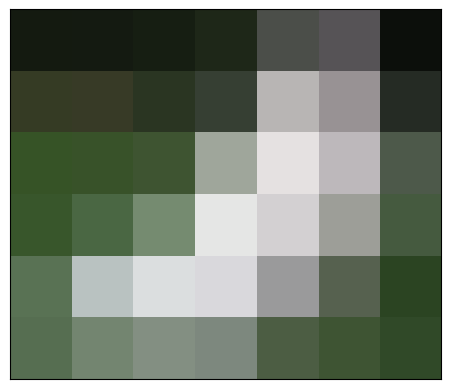

In [21]:
transforms = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.uint8, scale=True),
        v2.RandomHorizontalFlip(p=1.0),
        v2.Resize(size=(6,), max_size=None), # Reescala la imagen. Saldrá pixelada
    ]
)
out = transforms(img)
plt.xticks([])
plt.yticks([])
plt.imshow(out.permute(1, 2, 0).numpy())

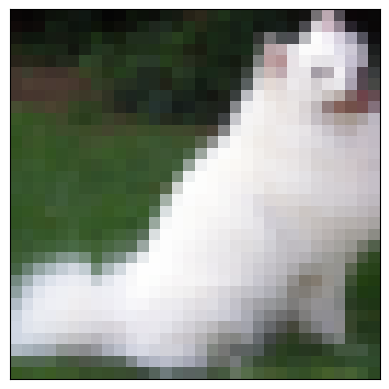

In [22]:
transforms = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.uint8, scale=True),
        v2.RandomHorizontalFlip(p=1.0),
        v2.Resize(size=36, max_size=None),
        v2.CenterCrop(size=32),     # Determina el zoom
    ]
)
out = transforms(img)
plt.xticks([])
plt.yticks([])
plt.imshow(out.permute(1, 2, 0).numpy())

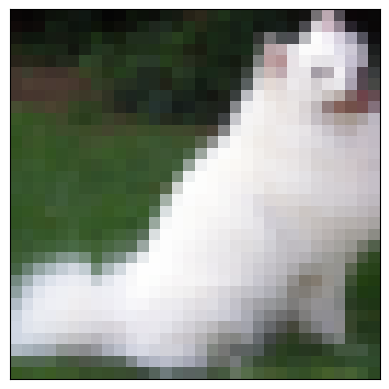

In [23]:
transforms = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.uint8, scale=True),
        v2.RandomHorizontalFlip(p=1.0),
        v2.Resize(size=36, max_size=None),
        v2.CenterCrop(size=(32, 32)),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=(0.0, 0.0, 0.0), std=(1.0, 1.0, 1.0)),
    ]
)
out = transforms(img)
plt.xticks([])
plt.yticks([])
plt.imshow(out.permute(1, 2, 0).numpy())

### Ejemplo


In [24]:
import torch
""" ESTE CODIGO SALE SIEMPRE: CODIGO DEL BUCLE DE ENTRENAMIENTO """

def exp(model, device, train_loader, test_loader, optimizer, scheduler, epochs=15):
    loss_fn = torch.nn.CrossEntropyLoss()
    for epoch in range(epochs):
        print(f"Epoch {epoch}: train:", end=" ")
        model.train()
        trsize, trbatches, trloss, tracc = 0, 0, 0, 0
        for batch in train_loader:
            X, y = batch["X"].to(device), batch["y"].to(device)
            trsize += len(X)
            trbatches += 1
            pred = model(X)
            loss = loss_fn(pred, y)
            trloss += loss.item()
            tracc += (pred.argmax(1) == y).type(torch.float).sum().item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            scheduler.step()
        trloss /= trbatches
        tracc /= trsize
        print(f"loss {trloss:g} acc {tracc:.2%} test:", end=" ")
        model.eval()
        tesize, tebatches, teloss, teacc = 0, 0, 0, 0
        with torch.no_grad():
            for batch in test_loader:
                X, y = batch["X"].to(device), batch["y"].to(device)
                tesize += len(X)
                tebatches += 1
                pred = model(X)
                teloss += loss_fn(pred, y).item()
                teacc += (pred.argmax(1) == y).type(torch.float).sum().item()
        teloss /= tebatches
        teacc /= tesize
        print(f"loss {teloss:g} acc {teacc:.2%}")

In [25]:
import datasets
from torch.utils.data import DataLoader

# CARGA DEL DATASET

ds = datasets.load_dataset("uoft-cs/cifar10").rename_columns({"img": "X", "label": "y"})
train_ds = ds["train"].to_iterable_dataset(num_shards=1024).shuffle()
test_ds = ds["test"].to_iterable_dataset(num_shards=1024)

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import timm

# CARGA DEL MODELO

device = (
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)
device
model_name = "resnet50.fb_swsl_ig1b_ft_in1k"  # avg_top1 71.5 param_count 25.56
model = timm.create_model(model_name, pretrained=True, num_classes=10).to(device)

In [27]:
# ADAPTAR EL MODELO A LAS DIMENSIONES DE LAS IMAGENES QUE VAMOS A UTILIZAR

data_cfg = timm.data.resolve_data_config(model.pretrained_cfg)
data_cfg

{'input_size': (3, 224, 224),
 'interpolation': 'bilinear',
 'mean': (0.485, 0.456, 0.406),
 'std': (0.229, 0.224, 0.225),
 'crop_pct': 0.875,
 'crop_mode': 'center'}

In [28]:
# Transofmración adaptada al tamaño de la imagen de CIFAR10

data_cfg["input_size"] = (3, 32, 32)
timm.data.create_transform(**data_cfg)

Compose(
    Resize(size=36, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(32, 32))
    MaybeToTensor()
    Normalize(mean=tensor([0.4850, 0.4560, 0.4060]), std=tensor([0.2290, 0.2240, 0.2250]))
)

In [29]:
from torchvision.transforms import v2

train_transform = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.uint8, scale=True),
        v2.RandomHorizontalFlip(),
        # v2.Resize(size=36, max_size=None),
        # v2.CenterCrop(size=(32, 32)),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=data_cfg["mean"], std=data_cfg["std"]),
    ]
)

# Mapeamos el dataset
def train_prep(example):
    return {"X": train_transform(example["X"]), "y": example["y"]}


train_ds = train_ds.map(train_prep, batched=True)
train_loader = DataLoader(train_ds, batch_size=32)

In [30]:
# LOS DATOS DE ENTRENAMIENTOS LOS TRANFORMAMOS, PERO NO TOCAMOS LOS DE TEST

test_transform = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=data_cfg["mean"], std=data_cfg["std"]),
    ]
)


def test_prep(example):
    return {"X": test_transform(example["X"]), "y": example["y"]}


test_ds = test_ds.map(test_prep, batched=True)
test_loader = DataLoader(test_ds, batch_size=32)

In [31]:
# EJECUCIÓN DEL EXPERIMENTO
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3
)
steps = 20
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, steps, eta_min=1e-4)
exp(model, device, train_loader, test_loader, optimizer, scheduler, epochs=steps)

Epoch 0: train: loss 1.99189 acc 38.85% test: loss 2.34136 acc 45.37%
Epoch 1: train: loss 1.64649 acc 46.54% test: loss 3.4169 acc 47.45%
Epoch 2: train: loss 1.13942 acc 61.85% test: loss 0.948903 acc 66.95%
Epoch 3: train: loss 0.95299 acc 68.29% test: loss 0.903032 acc 69.06%
Epoch 4: train: loss 0.787364 acc 73.48% test: loss 0.783284 acc 72.73%
Epoch 5: train: loss 0.684693 acc 77.10% test: loss 0.69022 acc 76.76%
Epoch 6: train: loss 0.609104 acc 79.59% test: loss 0.6206 acc 78.99%
Epoch 7: train: 

KeyboardInterrupt: 

### EJERCICIO: 

In [ ]:
# MNIST

# Bucle de entrenamiento:
def exp(model, device, train_loader, test_loader, optimizer, scheduler, epochs=15):
    loss_fn = torch.nn.CrossEntropyLoss()
    for epoch in range(epochs):
        print(f"Epoch {epoch}: train:", end=" ")
        model.train()
        trsize, trbatches, trloss, tracc = 0, 0, 0, 0
        for batch in train_loader:
            X, y = batch["X"].to(device), batch["y"].to(device)
            trsize += len(X)
            trbatches += 1
            pred = model(X)
            loss = loss_fn(pred, y)
            trloss += loss.item()
            tracc += (pred.argmax(1) == y).type(torch.float).sum().item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            scheduler.step()
        trloss /= trbatches
        tracc /= trsize
        print(f"loss {trloss:g} acc {tracc:.2%} test:", end=" ")
        model.eval()
        tesize, tebatches, teloss, teacc = 0, 0, 0, 0
        with torch.no_grad():
            for batch in test_loader:
                X, y = batch["X"].to(device), batch["y"].to(device)
                tesize += len(X)
                tebatches += 1
                pred = model(X)
                teloss += loss_fn(pred, y).item()
                teacc += (pred.argmax(1) == y).type(torch.float).sum().item()
        teloss /= tebatches
        teacc /= tesize
        print(f"loss {teloss:g} acc {teacc:.2%}")


# Se carga el dataseet de MNISTa
ds = datasets.load_dataset("ylecun/mnist").rename_columns({"image": "X", "label": "y"})
train_ds = ds["train"].to_iterable_dataset(num_shards=1024).shuffle()   # set de entrenamiento
test_ds = ds["test"].to_iterable_dataset(num_shards=1024)   # set de test

# Se carga el modelo a entrenar
device = (
    torch.accelerator.current_accelerator().type        # Seleccionamos el dispositivo a utilizar (CPU / GPU)
    if torch.accelerator.is_available()
    else "cpu"
)
device
model_name = "resnet50.fb_swsl_ig1b_ft_in1k"  # avg_top1 71.5 param_count 25.56 # Descargamos un modelo preentrenado (general)
model = timm.create_model(model_name, pretrained=True, num_classes=10).to(device) # Creaamos el modelo
#   pretrained = True --> carga pesos ya entrenados         num_classes = 10 --> cambia la ultima capa para que clasifique en 10 clases     to(device)--> Mete el modelo en el dispositivo



data_cfg = timm.data.resolve_data_config(model.pretrained_cfg)  # Obtiene la conf de preprocesamiento que el modelo espera.
data_cfg


# Realizamos las transformaciones sobre los datos
train_transform = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.uint8, scale=True),
        v2.RandomHorizontalFlip(),              # Aplicamos una transformación sobre la image
        # v2.Resize(size=36, max_size=None),
        # v2.CenterCrop(size=(32, 32)),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=data_cfg["mean"], std=data_cfg["std"]),
    ]
)

# Mapeamos el dataset
def train_prep(example):
    return {"X": train_transform(example["X"]), "y": example["y"]}


train_ds = train_ds.map(train_prep, batched=True)
train_loader = DataLoader(train_ds, batch_size=32)


# NO TRANSFORMAMOS LOS DATOS DE TEST.
test_transform = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=data_cfg["mean"], std=data_cfg["std"]),
    ]
)


def test_prep(example):
    return {"X": test_transform(example["X"]), "y": example["y"]}


test_ds = test_ds.map(test_prep, batched=True)
test_loader = DataLoader(test_ds, batch_size=32) # float 32 para que lo pueda procesar el modelo

In [36]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3
)
steps = 15 # él ha modificado esto
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, steps, eta_min=1e-4)
exp(model, device, train_loader, test_loader, optimizer, scheduler, epochs=steps)

Epoch 0: train: loss 0.874485 acc 80.36% test: loss 1.80819 acc 68.29%
Epoch 1: train: loss 0.236068 acc 93.20% test: loss 0.0823289 acc 97.60%
Epoch 2: train: loss 0.258385 acc 93.69% test: loss 0.0826317 acc 97.50%
Epoch 3: train: loss 0.119274 acc 96.77% test: loss 0.585274 acc 83.37%
Epoch 4: train: loss 0.104989 acc 97.12% test: loss 0.0614809 acc 98.18%
Epoch 5: train: loss 0.0759202 acc 97.85% test: loss 0.0344043 acc 98.88%
Epoch 6: train: 

KeyboardInterrupt: 

In [38]:
import datasets
from torch.utils.data import DataLoader

ds = datasets.load_dataset("zalando-datasets/fashion_mnist").rename_columns(
    {"image": "X", "label": "y"}
)
train_ds = ds["train"].to_iterable_dataset(num_shards=1024).shuffle()
test_ds = ds["test"].to_iterable_dataset(num_shards=1024)


import numpy as np
import matplotlib.pyplot as plt
import torch
import timm


device = (
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)
device
model_name = "resnet50.fb_swsl_ig1b_ft_in1k"  # avg_top1 71.5 param_count 25.56
model = timm.create_model(model_name, pretrained=True, num_classes=10, in_chans=1).to(
    device
)


from torchvision.transforms import v2

train_transform = v2.Compose(
    [
        v2.ToImage(),
        v2.RandomRotation(degrees=3),
        v2.RandomAffine(degrees=0, translate=(0.03, 0.03)),
        v2.ToDtype(torch.float32, scale=True),
    ]
)


def train_prep(example):
    return {"X": train_transform(example["X"]), "y": example["y"]}


train_ds = train_ds.map(train_prep, batched=True)
train_loader = DataLoader(train_ds, batch_size=32)
test_transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])


def test_prep(example):
    return {"X": test_transform(example["X"]), "y": example["y"]}


test_ds = test_ds.map(test_prep, batched=True)
test_loader = DataLoader(test_ds, batch_size=32)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3
)
steps = 15
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, steps, eta_min=1e-4)
exp(model, device, train_loader, test_loader, optimizer, scheduler, epochs=steps)

Epoch 0: train: loss 1.01261 acc 71.71% test: loss 0.717311 acc 79.55%
Epoch 1: train: loss 0.5868 acc 81.37% test: loss 0.496145 acc 82.12%
Epoch 2: train: loss 0.476756 acc 84.34% test: loss 1.16722 acc 83.57%
Epoch 3: train: 

KeyboardInterrupt: 